#  Data Challenge QRT - Analyse Exploratoire
## Prédiction de Survie Globale
---------
###  Objectif
Analyse exploratoire des données et le pipline

## 1. Imports et Configuration

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
# Configuration graphiques
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

##  2. Chargement des Données

In [71]:
# Chemins des données
BASE_DIR = Path('..')
# Chargement des données d'entraînement
clinical_train = pd.read_csv(BASE_DIR / 'X_train' / 'clinical_train.csv')
molecular_train = pd.read_csv(BASE_DIR / 'X_train' / 'molecular_train.csv')
y_train = pd.read_csv(BASE_DIR / 'target_train.csv')
# Chargement des données de test
clinical_test = pd.read_csv(BASE_DIR / 'X_test_xzVefmA' / 'X_test' / 'clinical_test.csv')
molecular_test = pd.read_csv(BASE_DIR / 'X_test_xzVefmA' / 'X_test' / 'molecular_test.csv')
print("RÉSUMÉ DES DONNÉES")
print("="*50)
print(f"\n Clinical Train : {clinical_train.shape[0]} patients × {clinical_train.shape[1]} variables")
print(f"Molecular Train: {molecular_train.shape[0]} mutations × {molecular_train.shape[1]} variables")
print(f"Y Train        : {y_train.shape[0]} patients × {y_train.shape[1]} variables")
print(f"\n Clinical Test  : {clinical_test.shape[0]} patients × {clinical_test.shape[1]} variables")
print(f" Molecular Test : {molecular_test.shape[0]} mutations × {molecular_test.shape[1]} variables")

RÉSUMÉ DES DONNÉES

 Clinical Train : 3323 patients × 9 variables
Molecular Train: 10935 mutations × 11 variables
Y Train        : 3323 patients × 3 variables

 Clinical Test  : 1193 patients × 9 variables
 Molecular Test : 3089 mutations × 11 variables


## Fusion données cliniques + targets

In [72]:
# Fusion clinical + target
df_train = clinical_train.merge(y_train, on='ID')
print(f"Dataset fusionné: {df_train.shape[0]} patients × {df_train.shape[1]} variables")
df_train.head()

Dataset fusionné: 3323 patients × 11 variables


,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,OS_YEARS,OS_STATUS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",1.115068,1.0
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx",4.928767,0.0
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",2.043836,0.0
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",2.476712,1.0
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",3.145205,0.0



##  3. Analyse des variables cibles 

In [73]:
print("="*60)
print(" VARIABLE CIBLE")
print("\n Variables:")
print(" OS_YEARS  : Temps de survie en années")
print(" OS_STATUS : 1 = décédé, 0 = censuré ")
print("\n Statistiques:")
print(y_train.describe())


 VARIABLE CIBLE

 Variables:
 OS_YEARS  : Temps de survie en années
 OS_STATUS : 1 = décédé, 0 = censuré 

 Statistiques:
          OS_YEARS    OS_STATUS
count  3173.000000  3173.000000
mean      2.480713     0.504255
std       2.588259     0.500061
min       0.000000     0.000000
25%       0.652055     0.000000
50%       1.652055     1.000000
75%       3.572603     1.000000
max      22.043836     1.000000


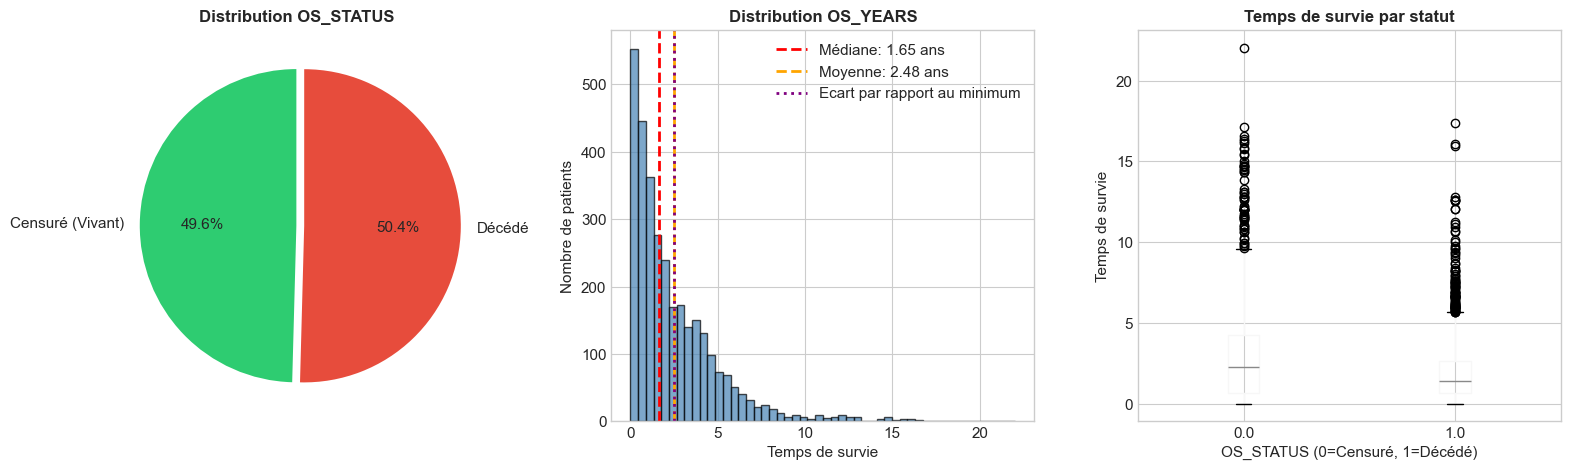


 Statistiques par statut:
            count      mean       std      min       25%       50%       75%  \
OS_STATUS                                                                      
0.0        1573.0  2.935222  2.963922  0.00000  0.632877  2.268493  4.221918   
1.0        1600.0  2.033873  2.061487  0.00274  0.669863  1.380822  2.670548   

                 max  
OS_STATUS             
0.0        22.043836  
1.0        17.375342  


In [74]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# 1. Pie chart OS_STATUS
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(status_counts.sort_index(), labels=['Censuré (Vivant)', 'Décédé'], autopct='%1.1f%%', colors=colors, explode=[0, 0.05], startangle=90)
axes[0].set_title('Distribution OS_STATUS', fontsize=12, fontweight='bold')
# 2. Histogramme OS_YEARS
axes[1].hist(y_train['OS_YEARS'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(y_train['OS_YEARS'].median(), color='red', linestyle='--', lw=2, label=f"Médiane: {y_train['OS_YEARS'].median():.2f} ans")
axes[1].axvline(y_train['OS_YEARS'].mean(), color='orange', linestyle='--', lw=2, label=f"Moyenne: {y_train['OS_YEARS'].mean():.2f} ans")
axes[1].axvline(y_train['OS_YEARS'].mean()- y_train['OS_YEARS'].min(), color='purple', linestyle=':', lw=2, label='Ecart par rapport au minimum')
axes[1].set_xlabel('Temps de survie')
axes[1].set_ylabel('Nombre de patients')
axes[1].set_title('Distribution OS_YEARS', fontsize=12, fontweight='bold')
axes[1].legend()

# 3. Boxplot par statut
df_train.boxplot(column='OS_YEARS', by='OS_STATUS', ax=axes[2])
axes[2].set_xlabel('OS_STATUS (0=Censuré, 1=Décédé)')
axes[2].set_ylabel('Temps de survie')
axes[2].set_title('Temps de survie par statut', fontsize=12, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\n Statistiques par statut:")
print(y_train.groupby('OS_STATUS')['OS_YEARS'].describe())

---


## 4. Analyse Univariée - Données Cliniques

In [75]:
print("="*60)
print(" DONNÉES CLINIQUES")
print("\n Description des variables:")
var_desc = {
    'ID': 'Identifiant unique patient',
    'CENTER': 'Centre clinique de traitement',
    'BM_BLAST': 'Blastes moelle osseuse (%) - cellules anormales',
    'WBC': 'Globules blancs (Giga/L)',
    'ANC': 'Neutrophiles absolus (Giga/L)',
    'MONOCYTES': 'Monocytes (Giga/L)',
    'HB': 'Hémoglobine (g/dL)',
    'PLT': 'Plaquettes (Giga/L)',
    'CYTOGENETICS': 'Caryotype - anomalies chromosomiques'
}
for var, desc in var_desc.items():
    print(f"  {var:12s}: {desc}")
print("\n Types de données:")
print(clinical_train.dtypes)

 DONNÉES CLINIQUES

 Description des variables:
  ID          : Identifiant unique patient
  CENTER      : Centre clinique de traitement
  BM_BLAST    : Blastes moelle osseuse (%) - cellules anormales
  WBC         : Globules blancs (Giga/L)
  ANC         : Neutrophiles absolus (Giga/L)
  MONOCYTES   : Monocytes (Giga/L)
  HB          : Hémoglobine (g/dL)
  PLT         : Plaquettes (Giga/L)
  CYTOGENETICS: Caryotype - anomalies chromosomiques

 Types de données:
ID               object
CENTER           object
BM_BLAST        float64
WBC             float64
ANC             float64
MONOCYTES       float64
HB              float64
PLT             float64
CYTOGENETICS     object
dtype: object


In [76]:
# Statistiques variables numériques
numeric_cols = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
print("\n Statistiques descriptives - Variables Numériques:")
clinical_train[numeric_cols].describe()


 Statistiques descriptives - Variables Numériques:


,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT
count,3214.000000,3051.000000,3130.000000,2722.000000,3213.000000,3199.000000
mean,5.982545,6.535164,3.264735,0.955868,9.893549,167.048900
std,7.615439,10.247219,5.237043,2.666478,2.041158,149.477031
min,0.000000,0.200000,0.000000,0.000000,4.000000,2.000000
25%,1.000000,2.700000,1.000000,0.150000,8.500000,65.500000
50%,3.000000,4.100000,2.000000,0.370000,9.700000,123.000000
75%,8.000000,6.655000,3.690000,0.783000,11.200000,229.500000
max,91.000000,154.400000,109.620000,44.200000,16.600000,1451.000000


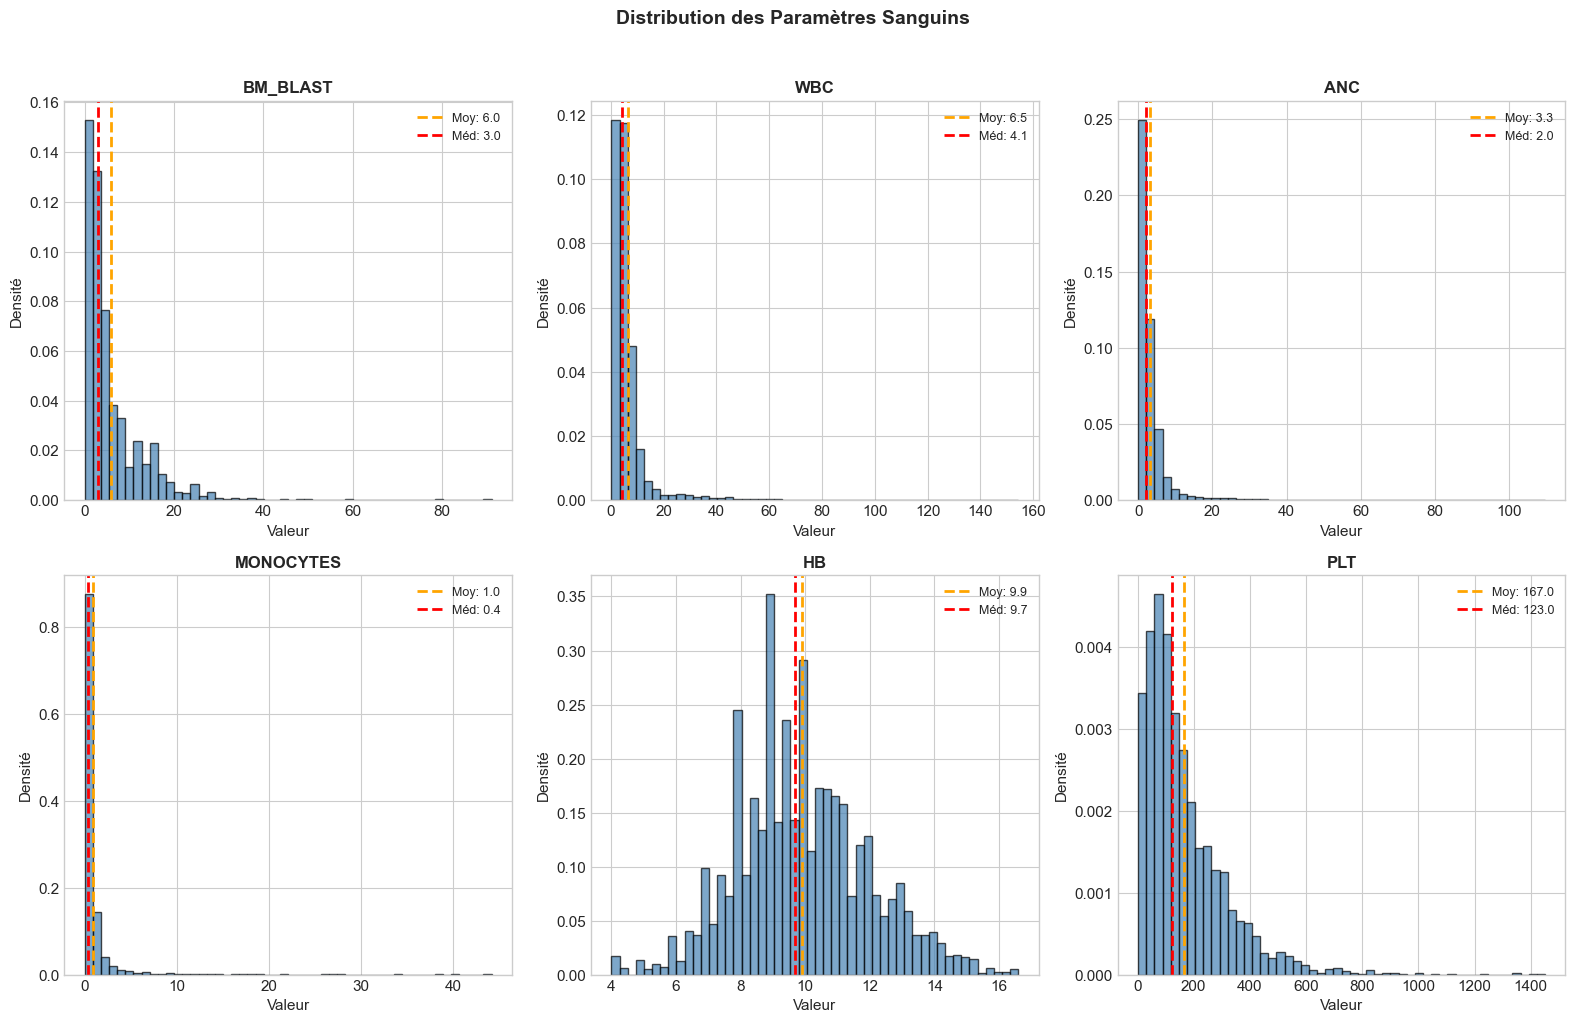

In [77]:
# Distribution des variables numériques
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = clinical_train[col].dropna()
    # Histogramme
    ax.hist(data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    # Statistiques
    ax.axvline(data.mean(), color='orange', linestyle='--', lw=2, label=f'Moy: {data.mean():.1f}')
    ax.axvline(data.median(), color='red', linestyle='--', lw=2, label=f'Méd: {data.median():.1f}')
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=9)
plt.suptitle('Distribution des Paramètres Sanguins', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

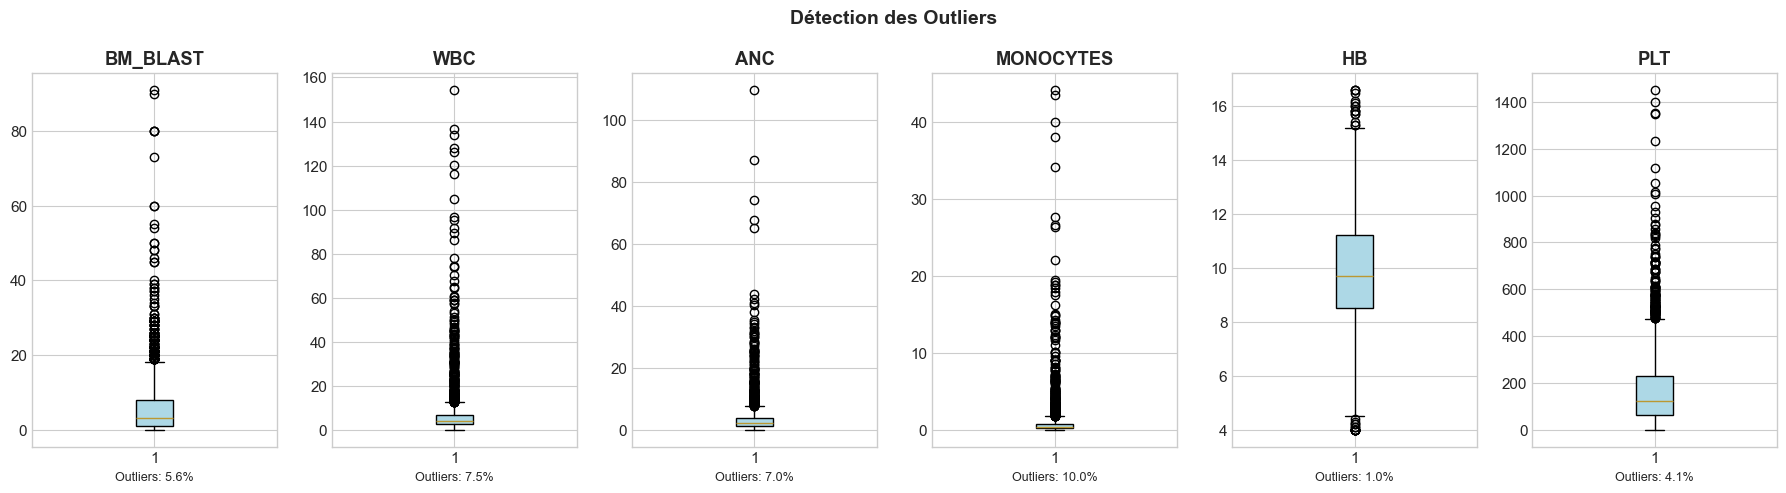

In [78]:
# Boxplots pour détecter les outliers
fig, axes = plt.subplots(1, 6, figsize=(18, 5))
for i, col in enumerate(numeric_cols):
    bp = axes[i].boxplot(clinical_train[col].dropna(), patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    axes[i].set_title(f'{col}', fontweight='bold')
    # Compter outliers
    Q1, Q3 = clinical_train[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = clinical_train[(clinical_train[col] < Q1 - 1.5*IQR) | 
                              (clinical_train[col] > Q3 + 1.5*IQR)][col]
    pct_outliers = len(outliers) / len(clinical_train[col].dropna()) * 100
    axes[i].set_xlabel(f'Outliers: {pct_outliers:.1f}%', fontsize=9)
plt.suptitle('Détection des Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Au vu de ces histogrammes les boxplots de ces variables numériques , on peux remarquer qu'il n'y'a pas trop de outlier très marquant , de plus, les distributions sont unimodal.**


 Distribution par Centre Clinique:
 Nombre de centres: 23


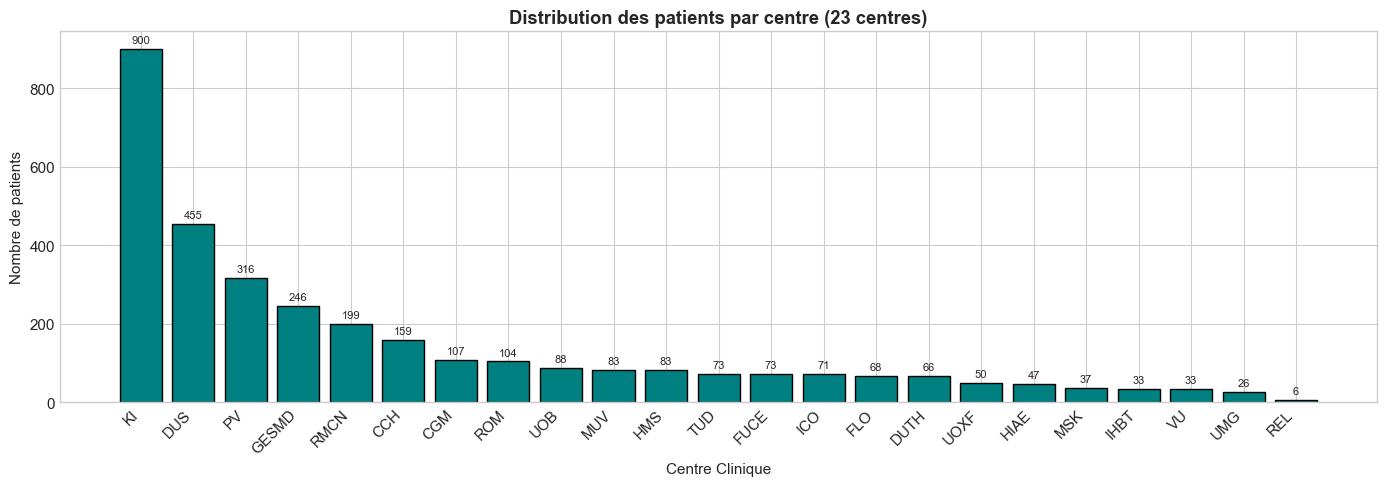


   Min: 6 patients | Max: 900 patients | Médiane: 73


In [79]:
# Analyse variable centre
print("\n Distribution par Centre Clinique:")
center_counts = clinical_train['CENTER'].value_counts()
print(f" Nombre de centres: {len(center_counts)}")
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(center_counts)), center_counts.values, color='teal', edgecolor='black')
ax.set_xticks(range(len(center_counts)))
ax.set_xticklabels(center_counts.index, rotation=45, ha='right')
ax.set_xlabel('Centre Clinique')
ax.set_ylabel('Nombre de patients')
ax.set_title(f'Distribution des patients par centre ({len(center_counts)} centres)', fontweight='bold')
# Annotations
for bar, val in zip(bars, center_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()
print(f"\n   Min: {center_counts.min()} patients | Max: {center_counts.max()} patients | Médiane: {center_counts.median():.0f}")

In [80]:
# Analyse CYTOGENETICS
print("\n Analyse CYTOGENETICS (Caryotype):")
print(f"Valeurs uniques: {clinical_train['CYTOGENETICS'].nunique()}")
print(f"Valeurs manquantes: {clinical_train['CYTOGENETICS'].isnull().sum()}")
# Top caryotypes
print("\n Les 10 premiers caryotypes:")
tcyto = clinical_train['CYTOGENETICS'].value_counts().head(10)
for i, (cyto, count) in enumerate(tcyto.items(), 1):
    pct = count / len(clinical_train) * 100
    print(f"{i:2d}. {count:4d} ({pct:5.2f}%) - {cyto[:50]}")


 Analyse CYTOGENETICS (Caryotype):
Valeurs uniques: 1194
Valeurs manquantes: 387

 Les 10 premiers caryotypes:
 1.  432 (13.00%) - 46,xy[20]
 2.  276 ( 8.31%) - 46,xy
 3.  254 ( 7.64%) - 46,xx[20]
 4.  192 ( 5.78%) - 46,xx
 5.   61 ( 1.84%) - 46,xy[25]
 6.   38 ( 1.14%) - 46,xx[25]
 7.   33 ( 0.99%) - 46,xy[21]
 8.   23 ( 0.69%) - 46,xx[26]
 9.   21 ( 0.63%) - 46,xy[26]
10.   18 ( 0.54%) - 46,xy[23]



 Analyse des patterns cytogénétiques:
   • Normal              : 1154 ( 34.7%)
   • Other abnormality   :  995 ( 29.9%)
   • Unknown             :  387 ( 11.6%)
   • Del 5q              :  302 (  9.1%)
   • Monosomy 7 (-7)     :  219 (  6.6%)
   • Trisomy 8           :  168 (  5.1%)
   • Del 20q             :   86 (  2.6%)
   • Complex             :   12 (  0.4%)


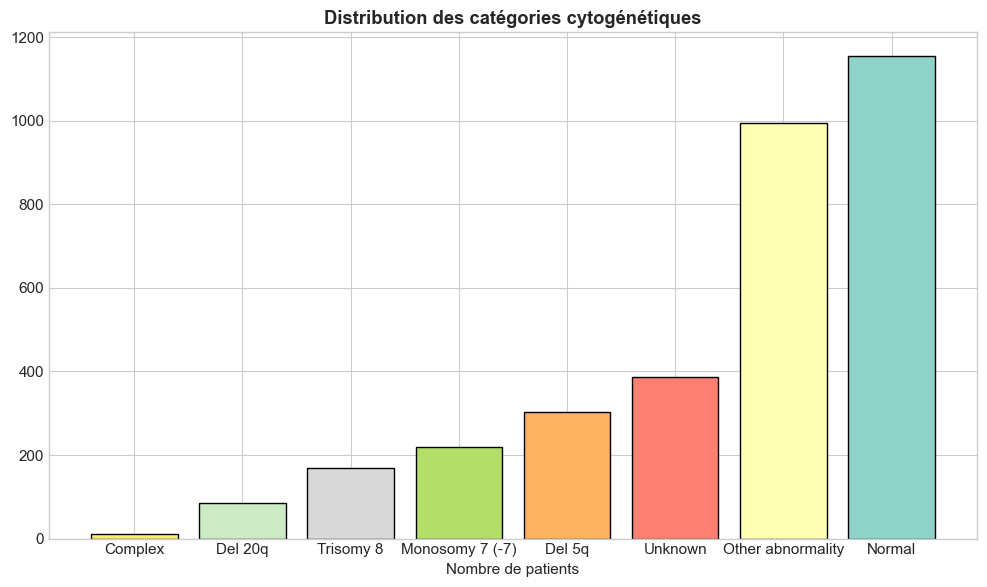

In [81]:
# Analyse des patterns CYTOGENETICS (créer des indices chromosomiques pour mieux visualiser les patients atteint d'anomalies)
print("\n Analyse des patterns cytogénétiques:")
# Créer des catégories simplifiées
def catecytogenetics(cyto):
    if pd.isna(cyto):
        return 'Unknown'
    cyto = str(cyto).lower()
    if cyto in ['normal', '46,xy', '46,xx', '46,xy[20]', '46,xx[20]']:
        return 'Normal'
    elif 'complex' in cyto:
        return 'Complex'
    elif '-7' in cyto or 'del(7)' in cyto:
        return 'Monosomy 7 (-7)'
    elif '-5' in cyto or 'del(5)' in cyto:
        return 'Del 5q'
    elif '+8' in cyto:
        return 'Trisomy 8'
    elif 'del(20)' in cyto:
        return 'Del 20q'
    else:
        return 'Other abnormality'
df_train['CYTO_CATEGORY'] = df_train['CYTOGENETICS'].apply(catecytogenetics)
# Distribution
cyto_counts = df_train['CYTO_CATEGORY'].value_counts()
for cat, count in cyto_counts.items():
    print(f"   • {cat:20s}: {count:4d} ({count/len(df_train)*100:5.1f}%)")
# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(cyto_counts)))
ax.bar(cyto_counts.index[::-1], cyto_counts.values[::-1], color=colors[::-1], edgecolor='black')
ax.set_xlabel('Nombre de patients')
ax.set_title('Distribution des catégories cytogénétiques', fontweight='bold')
plt.tight_layout()
plt.show()


##  5. Analyse des Données Moléculaires

In [82]:
print("="*60)
print(" DONNÉES MOLÉCULAIRES")

print(f"\n Dimensions: {molecular_train.shape[0]} mutations × {molecular_train.shape[1]} variables")
print(f" Patients avec mutations: {molecular_train['ID'].nunique()}")
print(f" Gènes uniques: {molecular_train['GENE'].nunique()}")

print("\n Variables:")
mol_desc = {
    'ID': 'Identifiant patient',
    'CHR': 'Chromosome',
    'START/END': 'Position génomique',
    'REF/ALT': 'Nucléotides référence/mutant',
    'GENE': 'Gène affecté',
    'PROTEIN_CHANGE': 'Impact sur la protéine',
    'EFFECT': "Type d'effet de la mutation",
    'VAF': 'Variant Allele Frequency (proportion de cellules mutées)',
    'DEPTH': 'Profondeur de séquençage'
}
for var, desc in mol_desc.items():
    print(f"   {var:15s}: {desc}")

molecular_train.head(10)

 DONNÉES MOLÉCULAIRES

 Dimensions: 10935 mutations × 11 variables
 Patients avec mutations: 3026
 Gènes uniques: 124

 Variables:
   ID             : Identifiant patient
   CHR            : Chromosome
   START/END      : Position génomique
   REF/ALT        : Nucléotides référence/mutant
   GENE           : Gène affecté
   PROTEIN_CHANGE : Impact sur la protéine
   EFFECT         : Type d'effet de la mutation
   VAF            : Variant Allele Frequency (proportion de cellules mutées)
   DEPTH          : Profondeur de séquençage


,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
0,P100000,11,119149248.0,119149248.0,G,A,CBL,p.C419Y,non_synonymous_codon,0.0830,1308.0
1,P100000,5,131822301.0,131822301.0,G,T,IRF1,p.Y164*,stop_gained,0.0220,532.0
2,P100000,3,77694060.0,77694060.0,G,C,ROBO2,p.?,splice_site_variant,0.4100,876.0
3,P100000,4,106164917.0,106164917.0,G,T,TET2,p.R1262L,non_synonymous_codon,0.4300,826.0
4,P100000,2,25468147.0,25468163.0,ACGAAGAGGGGGTGTTC,A,DNMT3A,p.E505fs*141,frameshift_variant,0.0898,942.0
5,P100001,22,29091725.0,29091725.0,C,T,CHEK2,p.W454*,stop_gained,0.4180,514.0
6,P100001,3,178936091.0,178936091.0,G,A,PIK3CA,p.E545K,non_synonymous_codon,0.1010,558.0
7,P100002,3,178936091.0,178936091.0,G,A,PIK3CA,p.E545K,non_synonymous_codon,0.1970,310.0
8,P100002,17,7579533.0,7579533.0,G,A,TP53,p.Q52*,stop_gained,0.5970,487.0
9,P100004,X,123190080.0,123190081.0,C,CA,STAG2,p.L436fs*5,frameshift_variant,0.4691,1296.0


In [83]:
# Patients SANS mutations
patients_with_mutations = set(molecular_train['ID'].unique())
all_patients = set(clinical_train['ID'].unique())
patients_without_mutations = all_patients - patients_with_mutations
print(f" Patients avec mutations    : {len(patients_with_mutations)}")
print(f"Patients SANS mutations    : {len(patients_without_mutations)}")
print(f"Pourcentage sans mutations : {len(patients_without_mutations)/len(all_patients)*100:.1f}%")

 Patients avec mutations    : 3026
Patients SANS mutations    : 297
Pourcentage sans mutations : 8.9%


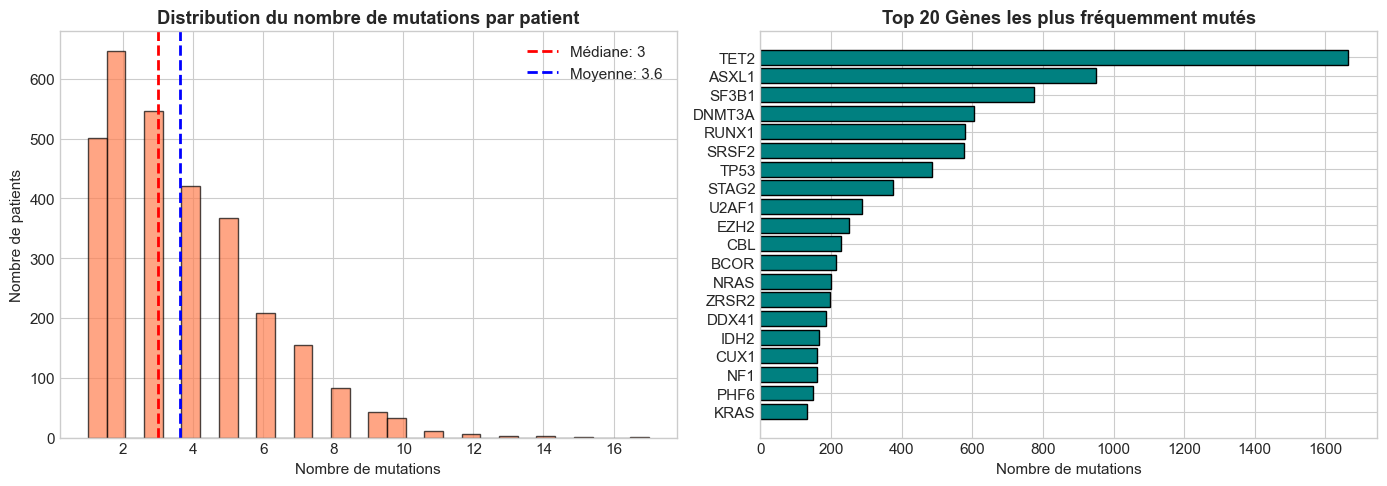


 Statistiques mutations/patient:
count    3026.000000
mean        3.613681
std         2.220222
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        17.000000
dtype: float64


In [84]:
# Nombre de mutations par patient
mutations_par_pat = molecular_train.groupby('ID').size()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Distribution
axes[0].hist(mutations_par_pat, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[0].axvline(mutations_par_pat.median(), color='red', linestyle='--', lw=2, label=f'Médiane: {mutations_par_pat.median():.0f}')
axes[0].axvline(mutations_par_pat.mean(), color='blue', linestyle='--', lw=2, label=f'Moyenne: {mutations_par_pat.mean():.1f}')
axes[0].set_xlabel('Nombre de mutations')
axes[0].set_ylabel('Nombre de patients')
axes[0].set_title('Distribution du nombre de mutations par patient', fontweight='bold')
axes[0].legend()
# Top gènes
top_genes = molecular_train['GENE'].value_counts().head(20)
axes[1].barh(top_genes.index[::-1], top_genes.values[::-1], color='teal', edgecolor='black')
axes[1].set_xlabel('Nombre de mutations')
axes[1].set_title('Top 20 Gènes les plus fréquemment mutés', fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\n Statistiques mutations/patient:")
print(mutations_par_pat.describe())

**Ce qui veut dire qu'en moyenne trois partient font des mutations celulaire et le gène dominant est le TET2**

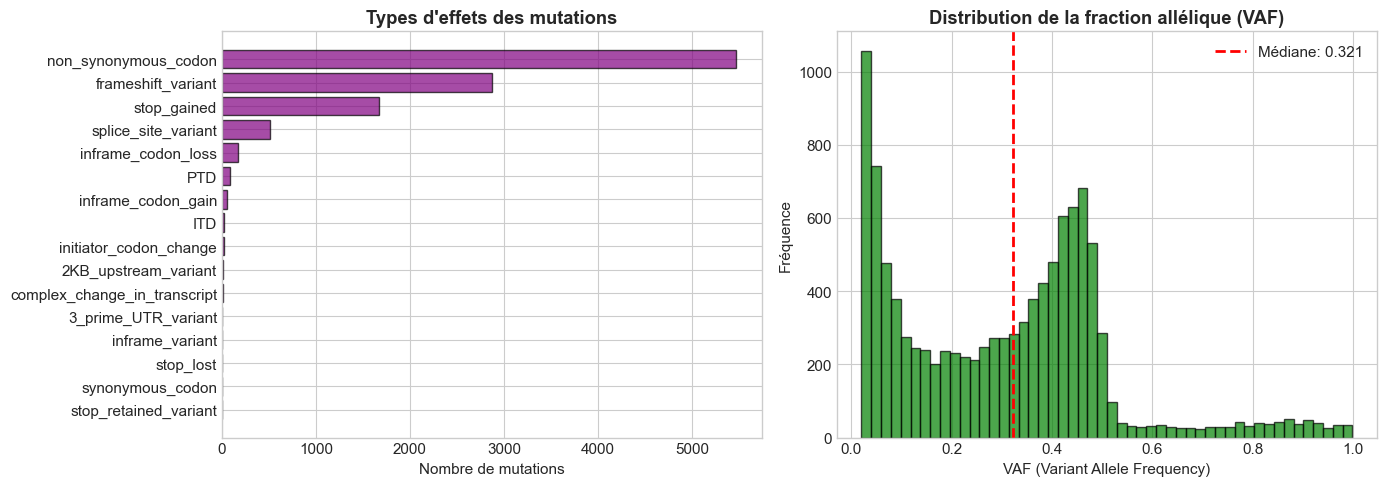

In [85]:
# Types d'effets des mutations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Effets
effect_counts = molecular_train['EFFECT'].value_counts()
axes[0].barh(effect_counts.index[::-1], effect_counts.values[::-1], color='purple', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Nombre de mutations')
axes[0].set_title("Types d'effets des mutations", fontweight='bold')
# Distribution VAF
axes[1].hist(molecular_train['VAF'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(molecular_train['VAF'].median(), color='red', linestyle='--', lw=2, label=f"Médiane: {molecular_train['VAF'].median():.3f}")
axes[1].set_xlabel('VAF (Variant Allele Frequency)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution de la fraction allélique (VAF)', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

**Ce test est particulièrement intéressant : on observe que la médiane de la proportion de gènes atteints par une mutation (VAF) est d’environ 0,3, ce qui indique un niveau de mutation modéré. Ce constat est cohérent avec ce que montrait déjà la description des variables cibles, à savoir un échantillon globalement presque équilibré**

---
## 6. Analyse Bivariée 

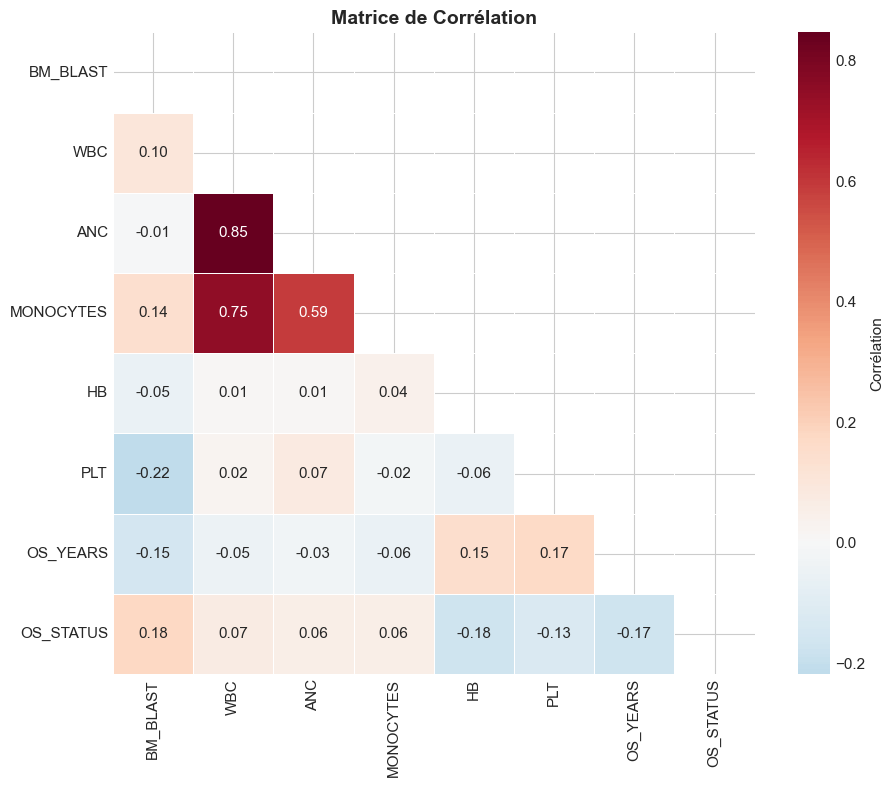

In [86]:
# Matrice de corrélation 
corr_cols = numeric_cols + ['OS_YEARS', 'OS_STATUS']
corr_matrix = df_train[corr_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Corrélation'})
ax.set_title('Matrice de Corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**La matrice de corrélation montre globalement peu de corrélations marquées entre les variables, à l’exception d’ANC et des monocytes qui sont fortement corrélées au nombre de globules blancs (WBC).**

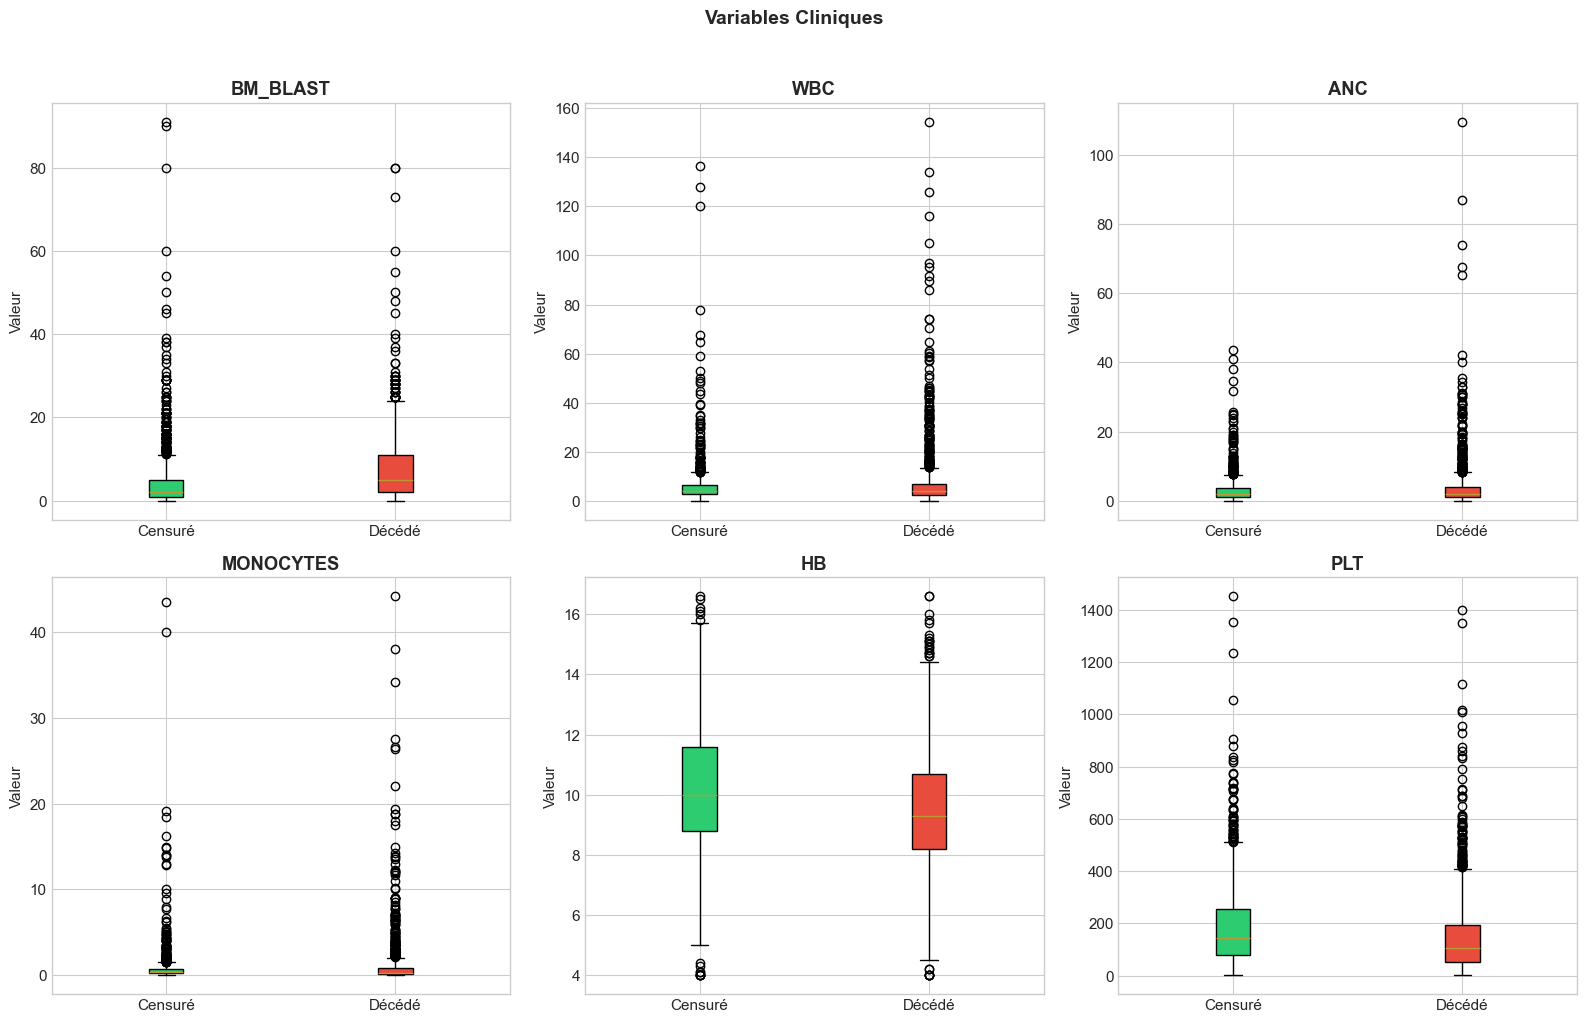

In [87]:
# Variations des variables par rapport à la variable catégorielle os_status
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    ax =axes[i]
    # Données par groupe
    alive = df_train[df_train['OS_STATUS'] == 0][col].dropna()
    deceased = df_train[df_train['OS_STATUS'] == 1][col].dropna()
    # Boxplot
    bp = ax.boxplot([alive, deceased], labels=['Censuré', 'Décédé'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_ylabel('Valeur')
plt.suptitle('Variables Cliniques', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**On observe sur ces figures que la modalité « décès » est particulièrement associée à des valeurs élevées de BM_BLAST. À l’inverse, pour HB et PLT, ce sont surtout les patients censurés qui sont majoritaires, tandis que pour les autres variables la différence entre groupes apparaît moins**

## Survie par centre clinique

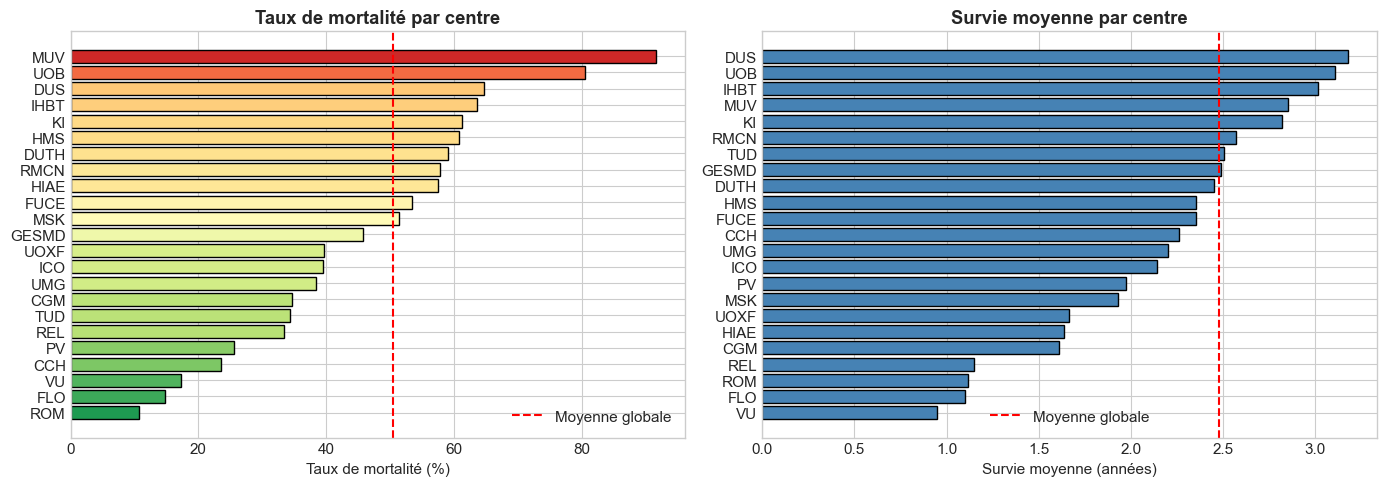

In [88]:
# Survie par centre clinique
survival_by_center = df_train.groupby('CENTER').agg({
    'OS_YEARS': 'mean',
    'OS_STATUS': 'mean',
    'ID': 'count'
}).rename(columns={'ID': 'n_patients', 'OS_STATUS': 'mortality_rate'})
survival_by_center = survival_by_center.sort_values('mortality_rate', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Taux de mortalité
colors = plt.cm.RdYlGn_r(survival_by_center['mortality_rate'].values)
axes[0].barh(survival_by_center.index[::-1], survival_by_center['mortality_rate'].values[::-1] * 100, color=colors[::-1], edgecolor='black')
axes[0].set_xlabel('Taux de mortalité (%)')
axes[0].set_title('Taux de mortalité par centre', fontweight='bold')
axes[0].axvline(df_train['OS_STATUS'].mean()*100, color='red', linestyle='--', label='Moyenne globale')
axes[0].legend()

# Survie moyenne
survival_by_center_sorted = survival_by_center.sort_values('OS_YEARS', ascending=False)
axes[1].barh(survival_by_center_sorted.index[::-1], survival_by_center_sorted['OS_YEARS'].values[::-1], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Survie moyenne (années)')
axes[1].set_title('Survie moyenne par centre', fontweight='bold')
axes[1].axvline(df_train['OS_YEARS'].mean(), color='red', linestyle='--', label='Moyenne globale')
axes[1].legend()
plt.tight_layout()
plt.show()


 Survie par catégorie cytogénétique:
                   mean_survival  median_survival  mortality_rate  n_patients
CYTO_CATEGORY                                                                
Complex                    2.075            0.603           0.917          12
Monosomy 7 (-7)            1.213            0.766           0.769         219
Trisomy 8                  1.867            1.219           0.627         168
Del 5q                     2.388            1.574           0.591         302
Unknown                    2.814            1.703           0.589         387
Del 20q                    2.224            1.567           0.494          86
Other abnormality          2.781            1.992           0.486         995
Normal                     2.500            1.849           0.393        1154


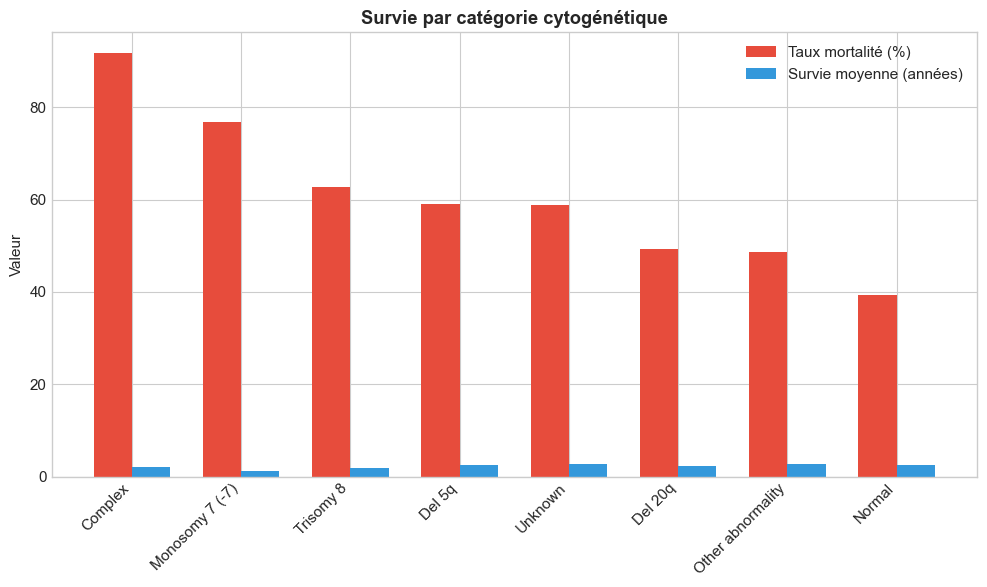

In [89]:
# Survie par catégorie cytogénétique
survival_by_cyto = df_train.groupby('CYTO_CATEGORY').agg({
    'OS_YEARS': ['mean', 'median'],
    'OS_STATUS': 'mean',
    'ID': 'count'
}).round(3)
survival_by_cyto.columns = ['mean_survival', 'median_survival', 'mortality_rate', 'n_patients']
survival_by_cyto = survival_by_cyto.sort_values('mortality_rate', ascending=False)

print("\n Survie par catégorie cytogénétique:")
print(survival_by_cyto)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(survival_by_cyto))
width = 0.35
bars1 = ax.bar(x - width/2, survival_by_cyto['mortality_rate']*100, width, label='Taux mortalité (%)', color='#e74c3c')
bars2 = ax.bar(x + width/2, survival_by_cyto['mean_survival'], width, label='Survie moyenne (années)', color='#3498db')
ax.set_xticks(x)
ax.set_xticklabels(survival_by_cyto.index, rotation=45, ha='right')
ax.set_ylabel('Valeur')
ax.set_title('Survie par catégorie cytogénétique', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Cette représentation en barres montre qu’une proportion particulièrement élevée de décès est observée chez les patients présentant un caryotype complexe. Plus le caryotype s’éloigne du profil normal, plus il devient rare que les patients soient censurés, ce qui reflète un risque de décès plus important**


Impact des mutations sur la survie:


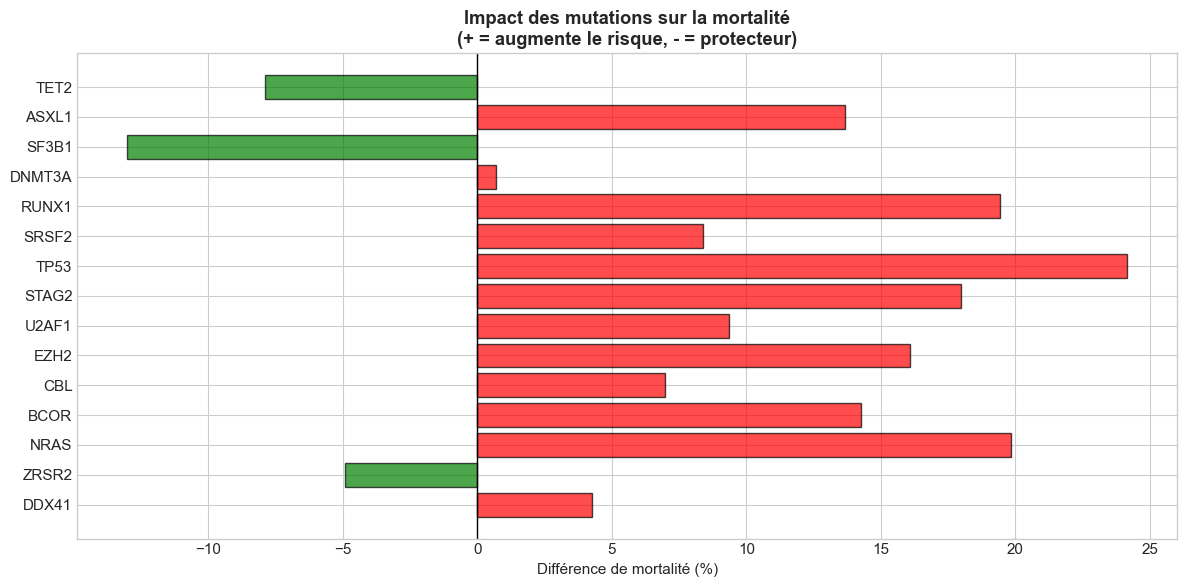

In [90]:
# Impact des mutations sur la survie
gene_presence = molecular_train.groupby(['ID', 'GENE']).size().unstack(fill_value=0)
gene_presence = (gene_presence > 0).astype(int)
# Joindre avec y_train
gene_survival = gene_presence.merge(y_train, left_index=True, right_on='ID')
top_genes = molecular_train['GENE'].value_counts().head(15).index.tolist()
print("\nImpact des mutations sur la survie:")
gene_st = []
for gene in top_genes:
    if gene in gene_survival.columns:
        with_mut = gene_survival[gene_survival[gene] == 1]
        without_mut = gene_survival[gene_survival[gene] == 0]
        surv_with = with_mut['OS_YEARS'].mean()
        surv_without = without_mut['OS_YEARS'].mean()
        mort_with = with_mut['OS_STATUS'].mean()
        mort_without = without_mut['OS_STATUS'].mean()
        diff_surv = surv_with - surv_without
        diff_mort = mort_with - mort_without
        gene_st.append({
            'gene': gene,
            'surv_diff': diff_surv,
            'mort_diff': diff_mort
        })
# Visualisation
gene_impact_df = pd.DataFrame(gene_st)
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['red' if x > 0 else 'green' for x in gene_impact_df['mort_diff']]
ax.barh(gene_impact_df['gene'][::-1], gene_impact_df['mort_diff'].values[::-1] * 100, color=colors[::-1], edgecolor='black', alpha=0.7)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Différence de mortalité (%)')
ax.set_title('Impact des mutations sur la mortalité\n(+ = augmente le risque, - = protecteur)', fontweight='bold')
plt.tight_layout()
plt.show()

**Certains gènes semblent avoir un effet protecteur lorsqu’ils sont mutés c’est notamment le cas du gène TET2, associé à une baisse du risque de décès. À l’inverse, des mutations du gène TP53 sont fortement liées à une augmentation du risque de mortalité.**

---
## 7. Analyse des Valeurs Manquantes

In [91]:
missing_clinical = clinical_train.isnull().sum()
missing_ = (missing_clinical / len(clinical_train) * 100).round(2)
missing_df = pd.DataFrame({
    'Variable': missing_clinical.index,
    'Manquantes': missing_clinical.values,
    'Pourcentage': missing_.values
}).sort_values('Pourcentage', ascending=False)

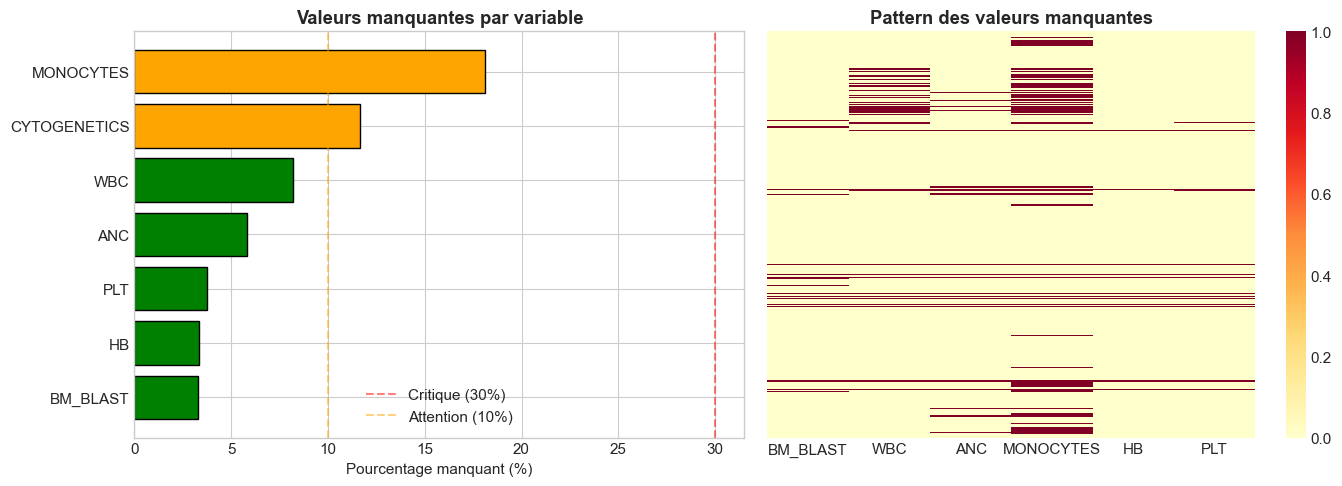

In [92]:
# Visualisation valeurs manquantes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Bar plot
missing_pct_sorted = missing_ [missing_ > 0].sort_values(ascending=True)
if len(missing_pct_sorted) > 0:
    colors = ['red' if x > 30 else 'orange' if x > 10 else 'green' for x in missing_pct_sorted.values]
    axes[0].barh(missing_pct_sorted.index, missing_pct_sorted.values, color=colors, edgecolor='black')
    axes[0].set_xlabel('Pourcentage manquant (%)')
    axes[0].set_title('Valeurs manquantes par variable', fontweight='bold')
    axes[0].axvline(30, color='red', linestyle='--', alpha=0.5, label='Critique (30%)')
    axes[0].axvline(10, color='orange', linestyle='--', alpha=0.5, label='Attention (10%)')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'Aucune valeur manquante', ha='center', va='center', fontsize=14)
    axes[0].axis('off')

# Heatmap pattern
sns.heatmap(clinical_train[numeric_cols].isnull(), cbar=True, yticklabels=False, ax=axes[1], cmap='YlOrRd')
axes[1].set_title('Pattern des valeurs manquantes', fontweight='bold')
plt.tight_layout()
plt.show()

In [93]:
for col in numeric_cols:
    missing_mask = df_train[col].isnull()
    if missing_mask.sum() > 10:  # Au moins 10 manquants
        surv_missing = df_train[missing_mask]['OS_YEARS'].mean()
        surv_present = df_train[~missing_mask]['OS_YEARS'].mean()
        mort_missing = df_train[missing_mask]['OS_STATUS'].mean()
        mort_present = df_train[~missing_mask]['OS_STATUS'].mean()
        print(f"\n   {col}:")
        print(f"Survie moyenne - Manquant: {surv_missing:.2f} ans | Présent: {surv_present:.2f} ans")
        print(f"Mortalité     - Manquant: {mort_missing*100:.1f}%    | Présent: {mort_present*100:.1f}%")


   BM_BLAST:
Survie moyenne - Manquant: 2.07 ans | Présent: 2.49 ans
Mortalité     - Manquant: 60.8%    | Présent: 50.2%

   WBC:
Survie moyenne - Manquant: 3.11 ans | Présent: 2.43 ans
Mortalité     - Manquant: 56.8%    | Présent: 49.9%

   ANC:
Survie moyenne - Manquant: 2.32 ans | Présent: 2.49 ans
Mortalité     - Manquant: 54.6%    | Présent: 50.2%

   MONOCYTES:
Survie moyenne - Manquant: 2.70 ans | Présent: 2.43 ans
Mortalité     - Manquant: 54.6%    | Présent: 49.6%

   HB:
Survie moyenne - Manquant: 2.45 ans | Présent: 2.48 ans
Mortalité     - Manquant: 49.3%    | Présent: 50.5%

   PLT:
Survie moyenne - Manquant: 2.30 ans | Présent: 2.49 ans
Mortalité     - Manquant: 47.7%    | Présent: 50.5%


**Les résultats suggèrent qu’un nombre élevé de valeurs manquantes est associé à une moins bonne survie. Cela peut refléter un suivi clinique incomplet ou une moindre observance des traitements chez ces patients.**